In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
usdt_data = pd.read_csv("USDT-USD.csv", usecols=["Date", "Close"], index_col=["Date"],parse_dates=["Date"])

In [3]:
usdt_data.head()

,Close
Date,
2017-11-09,1.00818
2017-11-10,1.00601
2017-11-11,1.00899
2017-11-12,1.01247
2017-11-13,1.00935


In [4]:
usdt_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1822 entries, 2017-11-09 to 2022-11-04
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1821 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


In [5]:
usdt_data.shape

(1822, 1)

In [6]:
usdt_data.isnull().sum()

Close    1
dtype: int64

In [7]:
usdt_data = usdt_data.dropna()

In [8]:
usdt_data.isnull().sum()

Close    0
dtype: int64

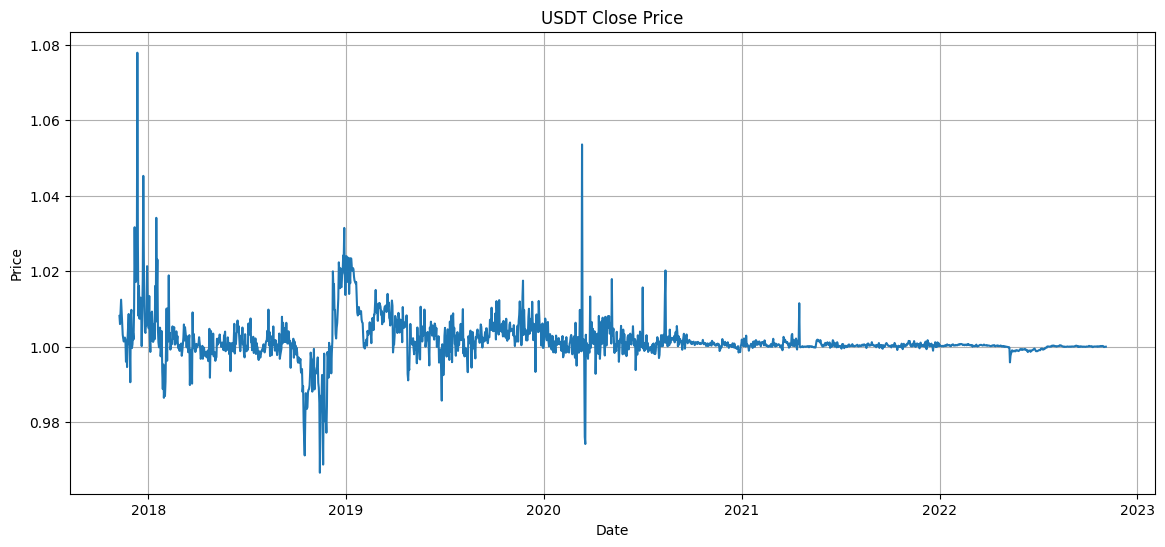

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(usdt_data.index, usdt_data.Close,)
plt.title("USDT Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

### Prophet

In [10]:
from prophet import Prophet

prophet_data = usdt_data.reset_index()

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### Rename

In [11]:
prophet_data = prophet_data.rename(columns={"Date":"ds", "Close":"y"})


In [12]:
prophet_data.head()

,ds,y
0,2017-11-09,1.00818
1,2017-11-10,1.00601
2,2017-11-11,1.00899
3,2017-11-12,1.01247
4,2017-11-13,1.00935


### Model Fit

In [13]:
model = Prophet()
model.fit(prophet_data)

18:40:52 - cmdstanpy - INFO - Chain [1] start processing
18:40:53 - cmdstanpy - INFO - Chain [1] done processing


### Make future dataframe

In [14]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

In [15]:
actual = usdt_data.copy()
actual["ds"] = actual.index
actual = actual.rename(columns={"Close": "actual"})
comparison = forecast[["ds", "yhat"]].merge(actual[["ds", "actual"]], on="ds")
comparison.tail(30).reset_index(drop=True)

,ds,yhat,actual
0,2022-10-05,0.999993,1.000109
1,2022-10-06,1.000312,1.000143
2,2022-10-07,0.999868,1.000122
3,2022-10-08,0.999950,1.000083
4,2022-10-09,0.999611,1.000158
5,2022-10-10,0.999130,1.000018
6,2022-10-11,0.999151,0.999901
7,2022-10-12,0.998889,0.999992
8,2022-10-13,0.999343,1.000079
9,2022-10-14,0.999054,1.000074


In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(comparison["actual"], comparison["yhat"])
print("MAE:", mae)

MAE: 0.0024182845029852556


In [17]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(comparison["actual"], comparison["yhat"]))
print("RMSE:", rmse)

RMSE: 0.0043472657049523225


In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(comparison["actual"],comparison["yhat"])
print("R²:", r2)

R²: 0.43566377144564983


In [19]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [20]:
# from sklearn.linear_model import LinearRegression
# model = LinearRegression()
# model.fit(X_train, y_train)
# prediction = model.predict(X_test)

In [21]:
# plt.figure(figsize=(10, 5))
# plt.plot(y_test, label= "Real")
# plt.plot(prediction, label= "predict")
# plt.legend()
# plt.show()